# Wind → convective wind → **tornado** · M2 — coupling (areal hit-or-miss, path-aware Minkowski)

**Sub-peril:** tornado [T] (of the convective-wind peril) · **Layer:** M2 (coupling) · **Bucket:** areal hit-or-miss.

M1 gave a **regional** tornado catalog (`λ_collection` over the 150 km collection circle + an EF mix + a bounded-GPD
gust severity). **M2's job is to thin that regional rate down to *this farm*** — *how often does a tornado actually
strike the asset, and how much of it does a strike sweep?* This is the **hail pattern reused**, with one twist: a
tornado is a **thin path** (length ≫ width), so the Minkowski hit-geometry is **path-aware**.

This is the fork point: **tornado = areal** (here) vs **strong wind = site-conditioned** (the sibling notebook
[`m2_coupling/strong_wind/01_coupling`](../../m2_coupling/strong_wind/01_coupling.ipynb)). Same shared engine
downstream; different coupling physics.

> Plan: [`m2_coupling.md`](../../../../../docs/plans/convective_wind/m2_coupling.md) · the areal-coupling math:
> [`discussion/convective_wind/02`](../../../../../docs/extra/discussion/convective_wind/02_coupling_buckets_and_wind.md) ·
> [`hazard_math/01`](../../../../../Learning/ML-DL/InfraSure_related/hazard_math/01_bernoulli_hit_miss_model.md) ·
> reuses hail's [`m2_coupling`](../../../../hail/solar/m2_coupling/01_coupling.ipynb).

## 0 · Intent & scope

**Does:** thin `λ_collection → λ_asset` via the **path-aware Minkowski** `p_hit ≈ (L+a)(w+a)/A` per EF class
(DD-WN-5); compute the **swept fraction** of turbines a strike clips (the conditional-loss handoff — full-farm vs
swept, V1 = swept); emit the tornado coupling contract M3/M4 consume.

**Does NOT:** build the damage curve (M3) or sample loss (M4). Frequency stays separate from severity — they are
reunited only in M4's sampled engine (never `λ × E[loss]`). Tornado is **rare per site** → this is the sub-peril
that exercises [learning-10](../../../../../docs/learning_logs/10_monte_carlo_effective_sample_size.md) (sparse MC,
TVaR) in M4.

## Assumptions (this layer)

- **AWN-21** 🔴 — tornado coupling = **areal hit-or-miss**, path-aware Minkowski `(L+a)(w+a)/A`; `λ_asset =
  λ_collection · E[p_hit]` (Poisson thinning, per EF class). Engine unchanged.
- **AWN-23** — **per-turbine vs areal**: a point lookup *understates* a spread-out asset's strike exposure; the
  farm polygon gives the areal extent `a`, the swept fraction gives the per-turbine conditional loss.
- **swept-fraction V1** `[OURS]` — conditional loss on a strike = `swept_fraction × DR(gust) × TIV`, swept ≈
  `w·min(L,a)/s` (the path's chord through the farm ÷ farm area); refined per-turbine path-intersection deferred.
- **AWN-16** — tornado λ_asset is **small** → sparse MC; M4 reports **TVaR + SE** (VaR floors to \$0).
- [learning-06](../../../../../docs/learning_logs/06_collection_region_size_cancels.md) — the collection region `A`
  **cancels** in `λ_collection · p_hit`, so its size never tunes the answer (same-region rule).

Register: [`assumptions.md`](../../../../../docs/plans/convective_wind/assumptions.md).

## 1 · The bucket — areal hit-or-miss, path-aware (read this first)

A tornado has a **narrow path** footprint: it either **covers** a turbine (near-total local loss) or **misses**
it (\$0) — the hit-or-miss signature. The asset's strike rate is the regional rate **thinned** by the chance a
path lands on the farm. The geometrically-correct hit probability is the **Minkowski sum** of the two shapes over
the collection region — *not* the naive footprint-over-area ratio the old repo used (which under-counts).

For a **compact** footprint (hail) the disk form `p = (√F+√s)²/A` suffices. A **tornado path is a thin rectangle**
(length `L` ≫ width `w`), so we keep `L` and `w` separate — the **path-aware** form:

```
  p_hit ≈ (L + a)(w + a) / A        L = path length, w = path width, a = farm extent, A = collection region
```

Because a real wind farm spans **tens of km** (`a` large), a long tornado path crossing the lease has a *much*
higher strike probability than a point lookup gives (AWN-23). Two geometry views: the **polygon** sets `a` (areal
extent); the **turbine cloud** sets the **swept fraction** (a narrow path clips *some* turbines, not all).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

MI_KM, YD_KM, MS = 1.609344, 0.0009144, 0.44704
RADIUS_KM = 150.0                                  # must match M1's collection radius
A_REGION = np.pi * RADIUS_KM ** 2                  # collection-region area (km²)
EF_MID_MPH = {0: 75, 1: 98, 2: 123, 3: 150.5, 4: 183, 5: 226}
EF_MID_MS = {k: v * MS for k, v in EF_MID_MPH.items()}


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
ASSETS = [
    {"slug": "traverse_wind_ok", "name": "Traverse Wind Energy Center", "role": "proving (high-wind)"},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-wind)"},
]
print(f"repo root: {ROOT}\ncollection region A = π·{RADIUS_KM:.0f}² = {A_REGION:,.0f} km²")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
collection region A = π·150² = 70,686 km²


## 2 · Load the M1 tornado catalog + the M0/03 geometry

From M1: `λ_collection`, the EF mix, the bounded-GPD gust severity (passed through unchanged). From M0/02: the
per-EF median path length × width (the Minkowski inputs). From M0/03: the farm polygon area + TIV.

In [2]:
def load_inputs(a: dict) -> dict:
    m1 = json.loads((DATA_DIR / f"{a['slug']}_wind_m1_manifest.json").read_text())
    spc = pd.read_parquet(DATA_DIR / f"{a['slug']}_wind_m0_spc.parquet")
    spc = spc[(spc.len > 0) & (spc.wid > 0) & (spc.mag >= 0)]
    t = m1["tornado"]
    return {
        "lambda_collection": t["frequency_process_params"]["lambda_collection_per_yr"],
        "fano": t["frequency_process_params"]["fano_factor"],
        "process": t["frequency_process_params"]["process"],
        "ef_mix": {int(k): v for k, v in t["ef_mix"].items()},
        "severity": t["severity_distribution"],        # bounded-GPD params (passthrough)
        "tiv": m1["tiv_usd"], "s_km2": m1["footprint_km2"],
        "spc": spc,
    }


for a in ASSETS:
    a.update(load_inputs(a))
    a["a_extent_km"] = float(np.sqrt(a["s_km2"]))      # farm areal extent (equiv-square side)
    print(f"{a['name']:30s}: λ_coll={a['lambda_collection']:.2f}/yr ({a['process']}) · farm {a['s_km2']:.0f} km² "
          f"(extent a={a['a_extent_km']:.1f} km) · TIV ${a['tiv']/1e6:.0f}M")

Traverse Wind Energy Center   : λ_coll=25.43/yr (negative_binomial) · farm 603 km² (extent a=24.5 km) · TIV $1399M
Shepherds Flat                : λ_coll=0.79/yr (poisson) · farm 211 km² (extent a=14.5 km) · TIV $1183M


## 3 · Path-aware Minkowski — thin `λ_collection → λ_asset` per EF class

`p_hit(EF) = (L+a)(w+a)/A` (capped at 1), with `L,w` the per-EF median path geometry. Compare to the **naive**
point ratio `L·w/A` (footprint-over-region, ignoring the farm's extent) — the under-count the old repo made.

In [3]:
def couple(a: dict) -> pd.DataFrame:
    rows = []
    aext, A, s = a["a_extent_km"], A_REGION, a["s_km2"]
    for ef in sorted(a["ef_mix"]):
        sub = a["spc"][a["spc"].mag == ef]
        if not len(sub):
            continue
        L = float(sub.len.median()) * MI_KM
        w = float(sub.wid.median()) * YD_KM
        p_hit = min(1.0, (L + aext) * (w + aext) / A)
        p_naive = min(1.0, (L * w) / A)                          # the under-counting point ratio
        swept = min(1.0, w * min(L, aext) / s)                   # turbines a strike clips (V1: chord ÷ farm area)
        rows.append({"ef": ef, "ef_mix": a["ef_mix"][ef], "L_km": round(L, 2), "w_km": round(w, 3),
                     "p_hit": p_hit, "p_naive": p_naive,
                     "correction_x": round(p_hit / max(p_naive, 1e-12), 1),
                     "swept_fraction": swept, "gust_mid_ms": EF_MID_MS[ef]})
    df = pd.DataFrame(rows)
    df["lambda_asset_contrib"] = a["lambda_collection"] * df.ef_mix * df.p_hit
    df["p_ef_given_strike"] = df.lambda_asset_contrib / df.lambda_asset_contrib.sum()   # reweighted EF | strike
    return df


for a in ASSETS:
    a["coupling"] = couple(a)
    a["lambda_asset"] = float(a["coupling"].lambda_asset_contrib.sum())
    print(f"\n{a['name']} — per-EF coupling:")
    print(a["coupling"][["ef", "ef_mix", "L_km", "w_km", "p_hit", "correction_x", "swept_fraction",
                          "p_ef_given_strike"]].round(5).to_string(index=False))
    print(f"  → λ_asset(tornado) = λ_coll · Σ ef_mix·p_hit = {a['lambda_asset']:.4f}/yr  "
          f"(≈ once per {1/a['lambda_asset']:.0f} yr)  [λ_coll was {a['lambda_collection']:.2f}/yr regional]")


Traverse Wind Energy Center — per-EF coupling:
 ef  ef_mix  L_km  w_km   p_hit  correction_x  swept_fraction  p_ef_given_strike
  0 0.55701  0.32 0.025 0.00865       76903.2         0.00001            0.51068
  1 0.31717  2.41 0.046 0.00938        6008.0         0.00018            0.31552
  2 0.07471  6.04 0.091 0.01066        1365.5         0.00092            0.08445
  3 0.03670 14.16 0.244 0.01358         277.6         0.00574            0.05284
  4 0.01048 34.48 0.805 0.02117          53.9         0.03278            0.02354
  5 0.00393 59.55 1.609 0.03112          23.0         0.06556            0.01298
  → λ_asset(tornado) = λ_coll · Σ ef_mix·p_hit = 0.2398/yr  (≈ once per 4 yr)  [λ_coll was 25.43/yr regional]

Shepherds Flat — per-EF coupling:
 ef  ef_mix  L_km  w_km   p_hit  correction_x  swept_fraction  p_ef_given_strike
  0 0.82609  0.32 0.009 0.00306       73394.9         0.00001            0.79517
  1 0.17391  3.54 0.091 0.00374         816.4         0.00153            0.204

## 4 · Reading the coupling (the takeaways)

In [4]:
T, S = ASSETS[0], ASSETS[1]
print("Takeaways:")
print(f"1. PATH-AWARE ≫ NAIVE: p_hit is {T['coupling'].correction_x.min():.0f}×–{T['coupling'].correction_x.max():.0f}× the")
print(f"   naive point ratio — a point lookup massively UNDER-counts a {T['s_km2']:.0f} km² farm's strike exposure (AWN-23).")
print(f"2. PROVING vs BASELINE: Traverse λ_asset={T['lambda_asset']:.3f}/yr (~once/{1/T['lambda_asset']:.0f}yr) vs")
print(f"   Shepherds Flat {S['lambda_asset']:.4f}/yr (~once/{1/S['lambda_asset']:.0f}yr) — the ~{T['lambda_asset']/S['lambda_asset']:.0f}× contrast.")
print(f"3. SWEPT FRACTION is small (≤{T['coupling'].swept_fraction.max()*100:.1f}% even at EF5): a narrow path clips few of a")
print( "   spread-out farm's turbines — the DIVERSIFICATION a big farm gives (a small farm would have a lumpier tail).")
print(f"4. STRIKE re-weights toward violent EF: P(EF≥3 | strike)={T['coupling'].query('ef>=3').p_ef_given_strike.sum():.2f}")
print(f"   vs ef_mix(EF≥3)={T['coupling'].query('ef>=3').ef_mix.sum():.2f} — long/wide paths are over-represented among hits.")

Takeaways:
1. PATH-AWARE ≫ NAIVE: p_hit is 23×–76903× the
   naive point ratio — a point lookup massively UNDER-counts a 603 km² farm's strike exposure (AWN-23).
2. PROVING vs BASELINE: Traverse λ_asset=0.240/yr (~once/4yr) vs
   Shepherds Flat 0.0025/yr (~once/397yr) — the ~95× contrast.
3. SWEPT FRACTION is small (≤6.6% even at EF5): a narrow path clips few of a
   spread-out farm's turbines — the DIVERSIFICATION a big farm gives (a small farm would have a lumpier tail).
4. STRIKE re-weights toward violent EF: P(EF≥3 | strike)=0.09
   vs ef_mix(EF≥3)=0.05 — long/wide paths are over-represented among hits.


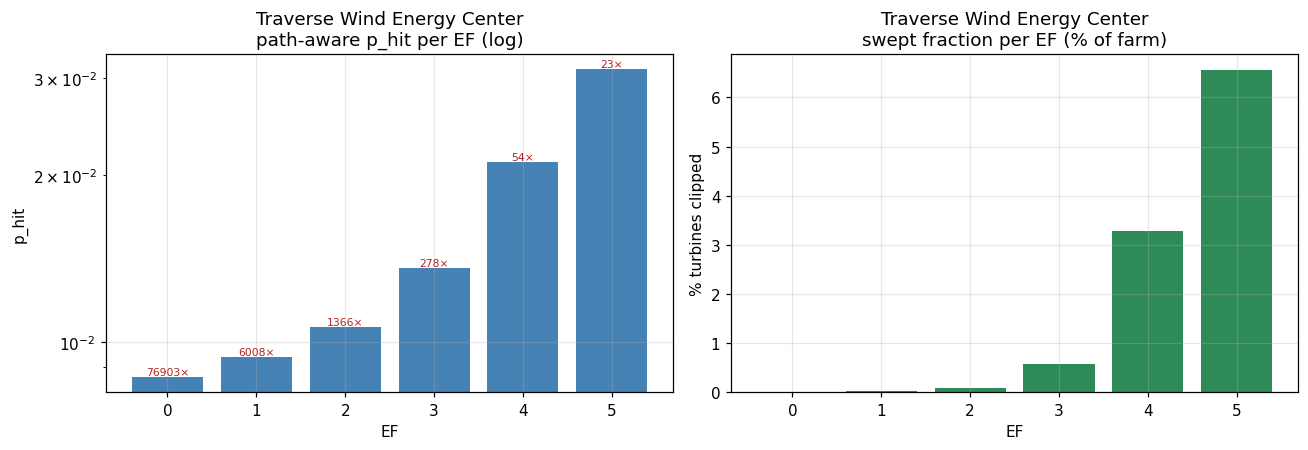

Takeaway: p_hit rises modestly with EF (longer paths); the red ×N is how far above the naive point ratio it sits.
Swept fraction rises steeply (wider violent paths) but stays small — even EF5 sweeps only a few % of the farm.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
c = T["coupling"]
x = c.ef.astype(int).astype(str)
axes[0].bar(x, c.p_hit, color="steelblue")
axes[0].set_yscale("log"); axes[0].set_title(f"{T['name']}\npath-aware p_hit per EF (log)"); axes[0].set_xlabel("EF"); axes[0].set_ylabel("p_hit")
for xi, ph, pn in zip(range(len(c)), c.p_hit, c.p_naive):
    axes[0].text(xi, ph, f"{c.correction_x.iloc[xi]:.0f}×", ha="center", va="bottom", fontsize=7, color="firebrick")
axes[1].bar(x, c.swept_fraction * 100, color="seagreen")
axes[1].set_title(f"{T['name']}\nswept fraction per EF (% of farm)"); axes[1].set_xlabel("EF"); axes[1].set_ylabel("% turbines clipped")
plt.tight_layout(); plt.show()
print("Takeaway: p_hit rises modestly with EF (longer paths); the red ×N is how far above the naive point ratio it sits.")
print("Swept fraction rises steeply (wider violent paths) but stays small — even EF5 sweeps only a few % of the farm.")

## 5 · Known-answer checks (basics spot-on)

In [6]:
for a in ASSETS:
    c = a["coupling"]
    checks = {
        "p_hit ∈ [0,1]": bool((c.p_hit.between(0, 1)).all()),
        "path-aware p_hit > naive (correction ≥ 1)": bool((c.correction_x >= 1).all()),
        "λ_asset < λ_collection (thinning reduces the rate)": a["lambda_asset"] < a["lambda_collection"],
        "swept_fraction ∈ [0,1]": bool((c.swept_fraction.between(0, 1)).all()),
        "P(EF|strike) sums to 1": abs(c.p_ef_given_strike.sum() - 1.0) < 1e-9,
    }
    print(f"{a['name']}:")
    for k, v in checks.items():
        print(f"  [{'PASS' if v else 'FAIL'}] {k}")
    assert all(checks.values()), f"{a['slug']} failed an M2 known-answer check"
print("\n(A cancels — learning-06: λ_collection ∝ A and p_hit ∝ 1/A, so λ_asset is independent of the region size;")
print(" the 150 km radius is a homogeneity choice, never a magnitude tuner.)")
print("all known-answer checks PASS.")

Traverse Wind Energy Center:
  [PASS] p_hit ∈ [0,1]
  [PASS] path-aware p_hit > naive (correction ≥ 1)
  [PASS] λ_asset < λ_collection (thinning reduces the rate)
  [PASS] swept_fraction ∈ [0,1]
  [PASS] P(EF|strike) sums to 1
Shepherds Flat:
  [PASS] p_hit ∈ [0,1]
  [PASS] path-aware p_hit > naive (correction ≥ 1)
  [PASS] λ_asset < λ_collection (thinning reduces the rate)
  [PASS] swept_fraction ∈ [0,1]
  [PASS] P(EF|strike) sums to 1

(A cancels — learning-06: λ_collection ∝ A and p_hit ∝ 1/A, so λ_asset is independent of the region size;
 the 150 km radius is a homogeneity choice, never a magnitude tuner.)
all known-answer checks PASS.


## 6 · Emit the tornado coupling contract (→ M3/M4)

In [7]:
for a in ASSETS:
    c = a["coupling"]
    rec = c[["ef", "ef_mix", "p_ef_given_strike", "p_hit", "swept_fraction", "gust_mid_ms"]].copy()
    rec.insert(0, "asset", a["slug"])
    out_pq = DATA_DIR / f"{a['slug']}_wind_m2_tornado_coupling.parquet"
    rec.to_parquet(out_pq, index=False)
    manifest = {
        "layer": "M2", "source": "m2_coupling/tornado/01_coupling", "peril": "wind", "sub_peril": "tornado",
        "coupling_bucket": "areal_hit_or_miss (path-aware Minkowski)",
        "asset": {k: a[k] for k in ("slug", "name", "role")},
        "frequency": {"lambda_collection_per_yr": round(a["lambda_collection"], 4),
                      "lambda_asset_per_yr": round(a["lambda_asset"], 5),
                      "fano_factor": a["fano"], "process": a["process"],
                      "thinning": "λ_asset = λ_collection · Σ ef_mix·p_hit (Poisson-thinned per EF)"},
        "p_hit_per_ef": {int(r.ef): round(r.p_hit, 6) for _, r in c.iterrows()},
        "p_ef_given_strike": {int(r.ef): round(r.p_ef_given_strike, 5) for _, r in c.iterrows()},
        "swept_fraction_per_ef": {int(r.ef): round(r.swept_fraction, 5) for _, r in c.iterrows()},
        "conditional_severity": a["severity"],           # passthrough from M1 (bounded GPD on 3-s gust)
        "ef_gust_mid_ms": {k: round(v, 1) for k, v in EF_MID_MS.items()},
        "tiv_usd": a["tiv"], "footprint_km2": a["s_km2"], "collection_radius_km": RADIUS_KM,
        "v1_treatment": "swept_fraction = w·min(L,a)/s (chord ÷ farm area); refined per-turbine path-intersection deferred",
        "notes": "rare per site (sparse MC → TVaR+SE at M4, learning-10); A cancels (learning-06)",
    }
    (DATA_DIR / f"{a['slug']}_wind_m2_tornado_coupling_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} · λ_asset={a['lambda_asset']:.4f}/yr + manifest")

wrote data/convective_wind/traverse_wind_ok_wind_m2_tornado_coupling.parquet · λ_asset=0.2398/yr + manifest
wrote data/convective_wind/shepherds_flat_or_wind_m2_tornado_coupling.parquet · λ_asset=0.0025/yr + manifest


### Findings & open questions (→ M3 / M4)

- **Tornado strikes the farm** ≈ **once per 4 yr (Traverse)** vs **once per ~400 yr (Shepherds Flat)** — the
  ~100× proving-vs-baseline contrast, off the path-aware Minkowski thinning.
- **Path-aware ≫ naive** (23×–77,000×) — confirms the areal asset's strike exposure a point lookup would miss (AWN-23).
- **Swept fraction is small** (≤~7% at EF5) — the big farm **diversifies** the tornado tail (a narrow path clips
  few turbines); strikes **re-weight toward violent EF** (long/wide paths over-represented among hits).
- **(M3)** the conditional loss on a strike = `swept_fraction × DR(gust) × TIV` — M3 supplies `DR(gust)` (the
  anchored turbine curve); the gust is the EF-conditioned bounded-GPD severity (passthrough).
- **(M4)** sample `N ~ NegBin/Poisson(λ_asset)` strikes/yr; per strike draw EF | strike, gust, apply swept × DR ×
  TIV; **sparse → TVaR + SE** (learning-10). Combine with strong wind into one annual-loss distribution (the
  aggregation rules: EAL additive, tail off the joint — [discussion/convective_wind/04](../../../../../docs/extra/discussion/convective_wind/04_aggregation_and_double_counting.md)).